# **Project 3 : House Predection**

## **Overview**

*   The main objective of this project (e.g., house predection based on historical data).
*   A brief explanation of the approaches used (Multiple Linear Regression, Random Forest and XGBoost).



## **Import Package**

In [1]:
#import the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.exceptions
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn import linear_model
from imblearn.over_sampling import SMOTE
from sklearn import metrics
from sklearn.linear_model import LogisticRegression
from sklearn import datasets, metrics, preprocessing, svm
from sklearn.metrics import precision_recall_fscore_support
from sklearn.metrics import classification_report,accuracy_score


## **Loading the Dataset**

In [2]:
#read dataset from gdrive
from google.colab import drive
drive.mount('/content/drive')

url = ('/content/drive/MyDrive/Fundamental ML/Project Assignment/Project 3 - House Predection/Dataset/train.csv')

# loading data
df = pd.read_csv(url)

df

Mounted at /content/drive


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [3]:
#Check Data information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

# **Step-Step of Analysis**

## **1. Preprocessing Data**


### 1.1 Checking Missing Value

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64


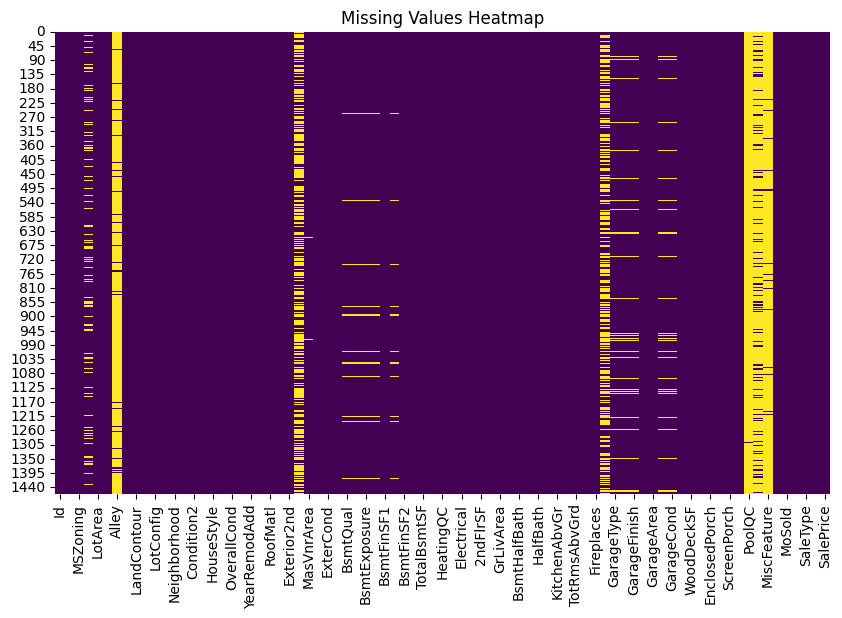


Number of columns with null values: 19
Columns with null values:
 ['LotFrontage', 'Alley', 'MasVnrType', 'MasVnrArea', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Electrical', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageQual', 'GarageCond', 'PoolQC', 'Fence', 'MiscFeature']


In [4]:
# prompt: create check missing value with chart heatmap and count columns is null

import matplotlib.pyplot as plt
# Check missing values and visualize with a heatmap
missing_values = df.isnull().sum()
print(missing_values)

plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

# Count columns with null values
null_columns = df.columns[df.isnull().any()]
print(f"\nNumber of columns with null values: {len(null_columns)}")
print(f"Columns with null values:\n {null_columns.tolist()}")


In [5]:
# prompt: get count null value percentage for every columns

# Calculate the percentage of null values for each column
null_percentage = df.isnull().sum() * 100 / len(df)

# Print the results
null_percentage


,0
Id,0.000000
MSSubClass,0.000000
MSZoning,0.000000
LotFrontage,17.739726
LotArea,0.000000
...,...
MoSold,0.000000
YrSold,0.000000
SaleType,0.000000
SaleCondition,0.000000


### 1.2 Selected Columns

In [6]:
# Display specific columns
selected_columns = df[['MSSubClass', 'MSZoning', 'LotArea','LotConfig','BldgType','OverallCond','YearBuilt','YearRemodAdd','Exterior1st','BsmtFinSF2','TotalBsmtSF','SalePrice']]
selected_columns

#Reference : https://www.geeksforgeeks.org/house-price-prediction-using-machine-learning-in-python/

,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0,856,208500
1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0,1262,181500
2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0,920,223500
3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0,756,140000
4,60,RL,14260,FR2,1Fam,5,2000,2000,VinylSd,0,1145,250000
...,...,...,...,...,...,...,...,...,...,...,...,...
1455,60,RL,7917,Inside,1Fam,5,1999,2000,VinylSd,0,953,175000
1456,20,RL,13175,Inside,1Fam,6,1978,1988,Plywood,163,1542,210000
1457,70,RL,9042,Inside,1Fam,9,1941,2006,CemntBd,0,1152,266500
1458,20,RL,9717,Inside,1Fam,6,1950,1996,MetalSd,1029,1078,142125


## **2. Exploratory Data Analysis (EDA) and Feature Engineering**

### 2.1 Correlation Matrix

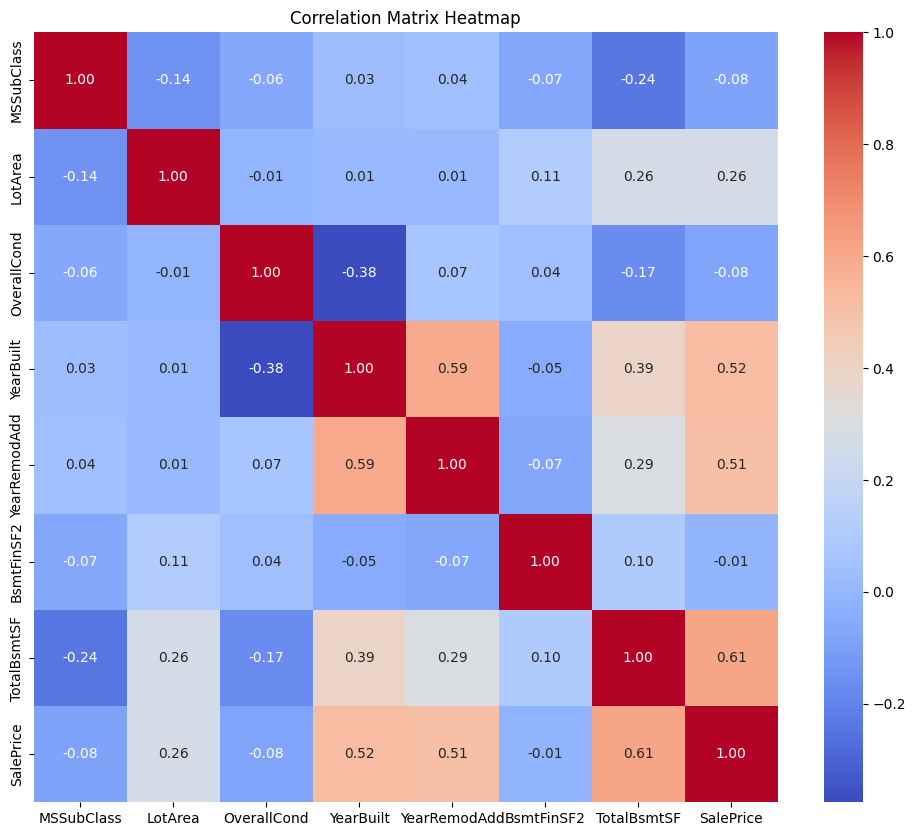

In [7]:
# prompt: buatkan correlation matrix dengan heatmap dari variable selected_columns

# Select only numerical columns for correlation calculation
numerical_columns = selected_columns.select_dtypes(include=['number'])

import matplotlib.pyplot as plt
# Calculate the correlation matrix
correlation_matrix = numerical_columns.corr()

# Create a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix Heatmap')
plt.show()


### 2.2 Feature Engineering

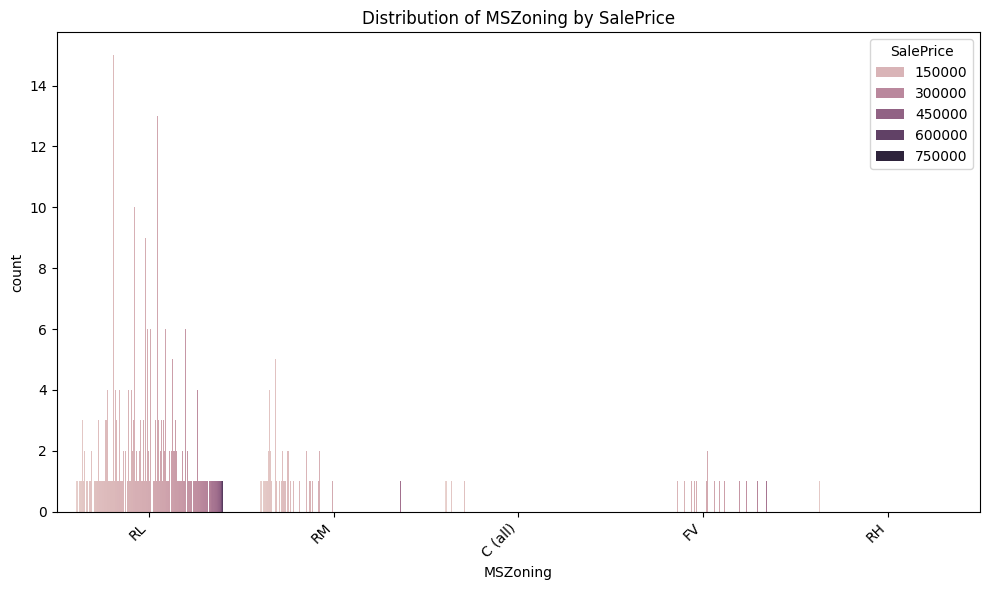

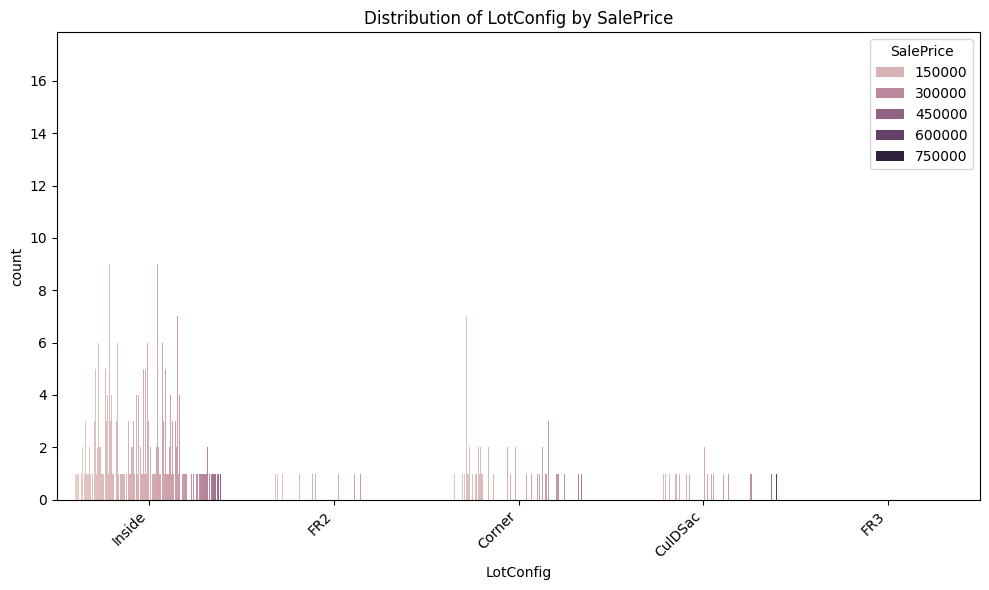

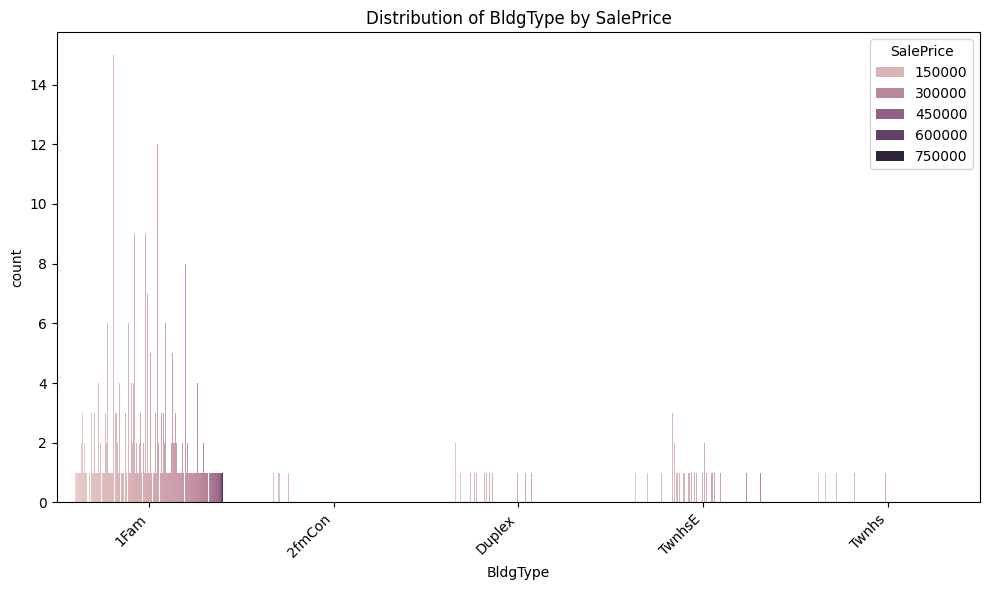

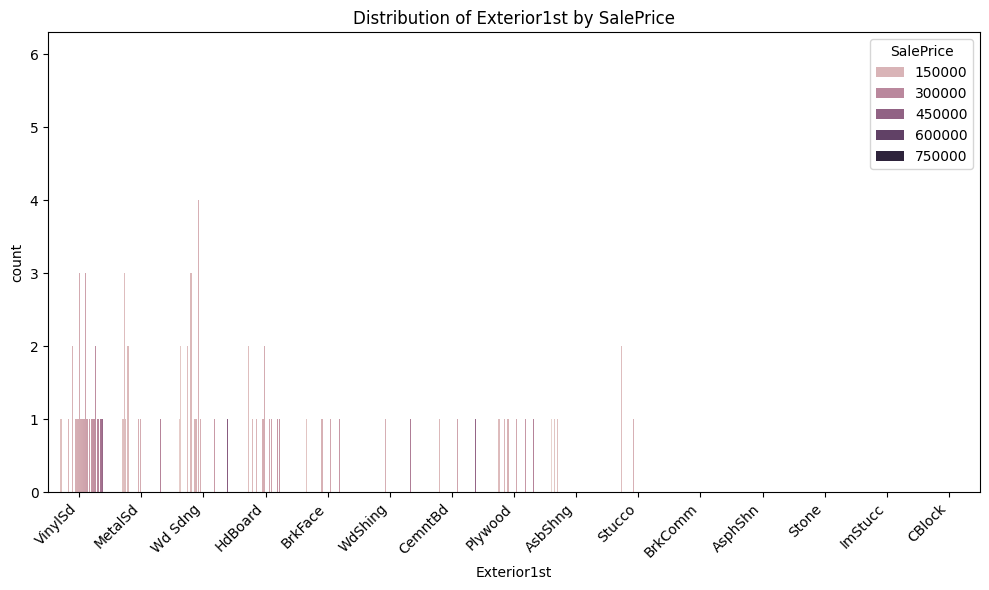

In [8]:
# prompt: buatlah analisa untuk setiap feature category berdasarkan selected column dan tampilkan dalam bar chart

import matplotlib.pyplot as plt
import seaborn as sns

def analyze_categorical_features(df, selected_column):
  """
  Analyzes categorical features based on a selected column and displays the results in bar charts.

  Args:
    df: The pandas DataFrame containing the data.
    selected_column: The name of the column to analyze against categorical features.
  """

  categorical_cols = df.select_dtypes(include=['object']).columns

  for col in categorical_cols:
      if col != selected_column:  # Exclude the selected column itself
          plt.figure(figsize=(10, 6))
          sns.countplot(x=col, hue=selected_column, data=df)
          plt.title(f'Distribution of {col} by {selected_column}')
          plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
          plt.tight_layout() # Adjust layout to prevent labels from overlapping
          plt.show()


# Example usage (assuming 'SalePrice' is the selected column):
analyze_categorical_features(selected_columns, 'SalePrice')


## 3 Splitting Dataset Training and Testing


In [9]:
# prompt: buatkan analisa splitting dataset training dan testing

import pandas as pd
# Separate features (X) and target variable (y)
X = selected_columns.drop('SalePrice', axis=1)
y = selected_columns['SalePrice']

# Convert categorical features to numerical using one-hot encoding
X = pd.get_dummies(X, drop_first=True)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # 80% training and 20% test

# Print the shapes of the resulting datasets to verify the split
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (1168, 33)
X_test shape: (292, 33)
y_train shape: (1168,)
y_test shape: (292,)


## **4. Modelling**

### 4.1 Linear Regression

#### Without Hyperparameter Tuning

Linear Regression - Mean Squared Error: 291845802958.55
Linear Regression - R-squared: 61.95%
Linear Regression Train - Mean Squared Error: 230094964054.43
Linear Regression Train - R-squared: 61.42%


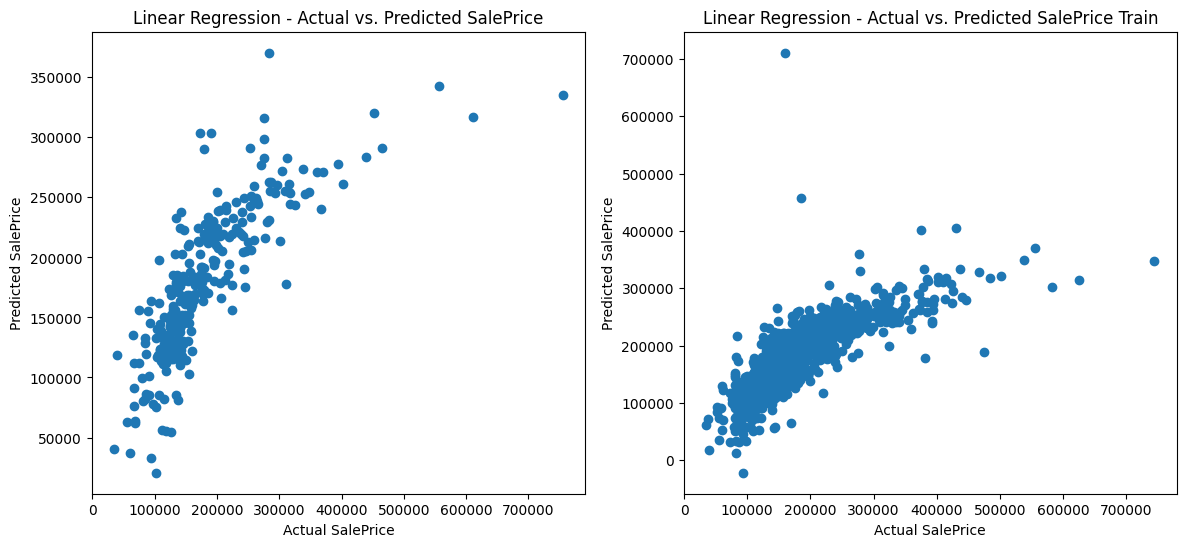

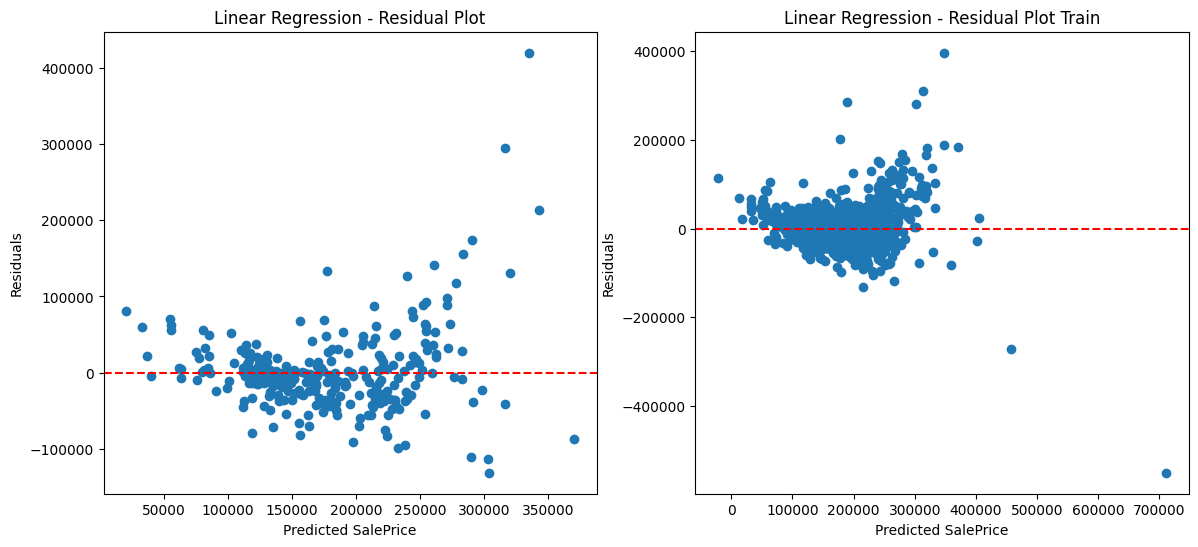

In [10]:
# prompt: buatkan analisa menggunakan model LinearRegression

import matplotlib.pyplot as plt
# Initialize and train the Linear Regression model
lr_model = linear_model.LinearRegression()
lr_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_lr = lr_model.predict(X_test)
y_pred_lr_train = lr_model.predict(X_train)

# Evaluate the model
mse_lr = metrics.mean_squared_error(y_test, y_pred_lr) * 100
r2_lr = metrics.r2_score(y_test, y_pred_lr) * 100

mse_lr_train = metrics.mean_squared_error(y_train, y_pred_lr_train) * 100
r2_lr_train = metrics.r2_score(y_train, y_pred_lr_train) * 100

print(f"Linear Regression - Mean Squared Error: {mse_lr:.2f}")
print(f"Linear Regression - R-squared: {r2_lr:.2f}%")

print(f"Linear Regression Train - Mean Squared Error: {mse_lr_train:.2f}")
print(f"Linear Regression Train - R-squared: {r2_lr_train:.2f}%")


#Further analysis (optional):
# You can analyze the coefficients to understand the impact of different features
# on the predicted SalePrice.
#print("Coefficients:", lr_model.coef_)
#print("Intercept:", lr_model.intercept_)

plt.figure(figsize=(14,6))
plt.subplot(1, 2, 1)
#Visualize predictions vs actual values
plt.scatter(y_test, y_pred_lr)
plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title("Linear Regression - Actual vs. Predicted SalePrice")


plt.subplot(1, 2, 2)
#Visualize predictions vs actual values Train
plt.scatter(y_train, y_pred_lr_train)
plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title("Linear Regression - Actual vs. Predicted SalePrice Train")
plt.show()

plt.figure(figsize=(14,6))
plt.subplot(1, 2, 1)
#Residual plot
residuals = y_test - y_pred_lr
plt.scatter(y_pred_lr, residuals)
plt.xlabel("Predicted SalePrice")
plt.ylabel("Residuals")
plt.title("Linear Regression - Residual Plot")
plt.axhline(y=0, color='r', linestyle='--') # Add a horizontal line at y=0

plt.subplot(1, 2, 2)
#Residual plot Train
residuals = y_train - y_pred_lr_train
plt.scatter(y_pred_lr_train, residuals)
plt.xlabel("Predicted SalePrice")
plt.ylabel("Residuals")
plt.title("Linear Regression - Residual Plot Train")
plt.axhline(y=0, color='r', linestyle='--') # Add a horizontal line at y=0
plt.show()


#### With Hyperparameter Tuning

In [11]:
# prompt: buatkan analisa dengan model LinearRegression dan hyperparameter tuning

from sklearn.model_selection import GridSearchCV

# Define the parameter grid for hyperparameter tuning
param_grid = {
    'fit_intercept': [True, False],
    'copy_X': [True, False]
}

# Create a GridSearchCV object
grid_search = GridSearchCV(estimator=lr_model, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error')

# Fit the grid search to the training data
grid_search.fit(X_train, y_train)

# Print the best parameters and the best score
print("Best Parameters:", grid_search.best_params_)
print("Best Score (Negative MSE):", grid_search.best_score_)

# Train the model with the best parameters
best_lr_model = linear_model.LinearRegression(**grid_search.best_params_)
best_lr_model.fit(X_train, y_train)

# Make predictions with the best model
y_pred_best_lr = best_lr_model.predict(X_test)
y_pred_best_lr_train = best_lr_model.predict(X_train)

# Evaluate the best model
mse_best_lr = metrics.mean_squared_error(y_test, y_pred_best_lr) * 100
r2_best_lr = metrics.r2_score(y_test, y_pred_best_lr) * 100

mse_best_lr_train = metrics.mean_squared_error(y_train, y_pred_best_lr_train) * 100
r2_best_lr_train = metrics.r2_score(y_train, y_pred_best_lr_train) * 100

print(f"Best Linear Regression - Mean Squared Error: {mse_best_lr:.2f}")
print(f"Best Linear Regression - R-squared: {r2_best_lr:.2f}%")

print(f"Best Linear Regression Train - Mean Squared Error: {mse_best_lr_train:.2f}")
print(f"Best Linear Regression Train - R-squared: {r2_best_lr_train:.2f}%")


Best Parameters: {'copy_X': True, 'fit_intercept': True}
Best Score (Negative MSE): -2540635982.649663
Best Linear Regression - Mean Squared Error: 291845802958.55
Best Linear Regression - R-squared: 61.95%
Best Linear Regression Train - Mean Squared Error: 230094964054.43
Best Linear Regression Train - R-squared: 61.42%


### 4.2 Random Forest

#### Without Hyperparameter Tuning

Random Forest - Mean Squared Error: 140759676342.44
Random Forest - R-squared: 81.65%
Random Forest - Mean Squared Error Train: 19790071510.31
Random Forest - R-squared Train: 96.68%
                Feature  Importance
3             YearBuilt    0.329993
6           TotalBsmtSF    0.311677
1               LotArea    0.164874
0            MSSubClass    0.052922
4          YearRemodAdd    0.048577
2           OverallCond    0.029044
31  Exterior1st_Wd Sdng    0.015114
21  Exterior1st_BrkFace    0.008971
14     LotConfig_Inside    0.005050
30  Exterior1st_VinylSd    0.005018


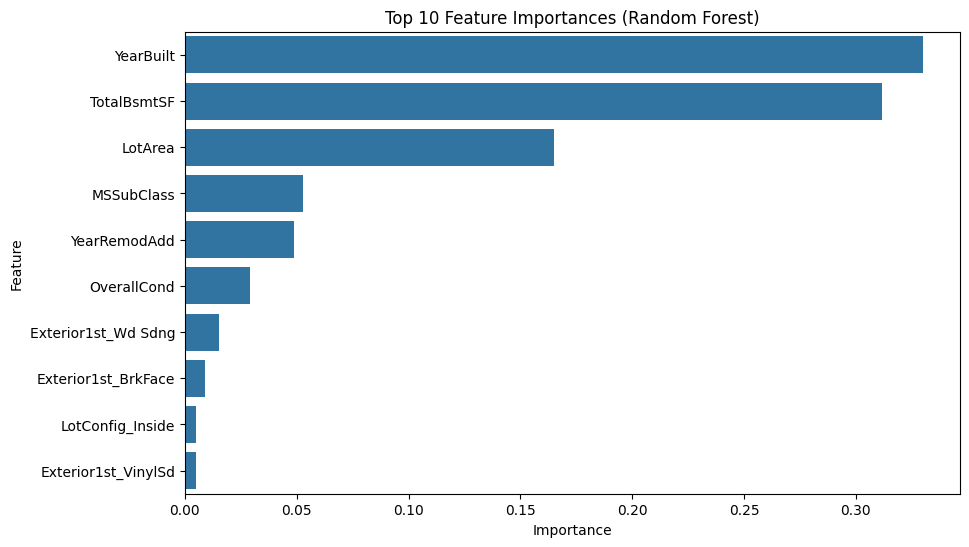

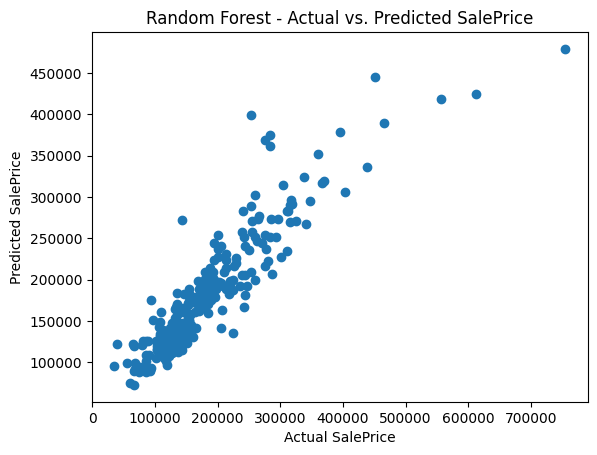

In [12]:
# prompt: buatkan analisa menggunakan model Random Forest

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

# Initialize and train the Random Forest model
rf_model = RandomForestRegressor(random_state=42)  # You can adjust hyperparameters here
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)
y_pred_rf_train = rf_model.predict(X_train)

# Evaluate the model
mse_rf = metrics.mean_squared_error(y_test, y_pred_rf) * 100
r2_rf = metrics.r2_score(y_test, y_pred_rf) * 100

mse_rf_train = metrics.mean_squared_error(y_train, y_pred_rf_train) * 100
r2_rf_train = metrics.r2_score(y_train, y_pred_rf_train) * 100

print(f"Random Forest - Mean Squared Error: {mse_rf:.2f}")
print(f"Random Forest - R-squared: {r2_rf:.2f}%")
print(f"Random Forest - Mean Squared Error Train: {mse_rf_train:.2f}")
print(f"Random Forest - R-squared Train: {r2_rf_train:.2f}%")

# Feature Importance
feature_importances = rf_model.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': feature_importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
print(feature_importance_df.head(10)) # Print top 10 features

# Visualize feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10))
plt.title('Top 10 Feature Importances (Random Forest)')
plt.show()

#Visualize predictions vs actual values
plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title("Random Forest - Actual vs. Predicted SalePrice")
plt.show()


#### With Hyperparameter Tuning

Best Parameters (Random Forest): {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Best Score (Negative MSE) (Random Forest): -1356790910.7973862
Best Random Forest - Mean Squared Error: 126400648723.26
Best Random Forest - R-squared: 83.52%
Best Random Forest - Mean Squared Error Train: 35963816335.41
Best Random Forest - R-squared Train: 93.97%


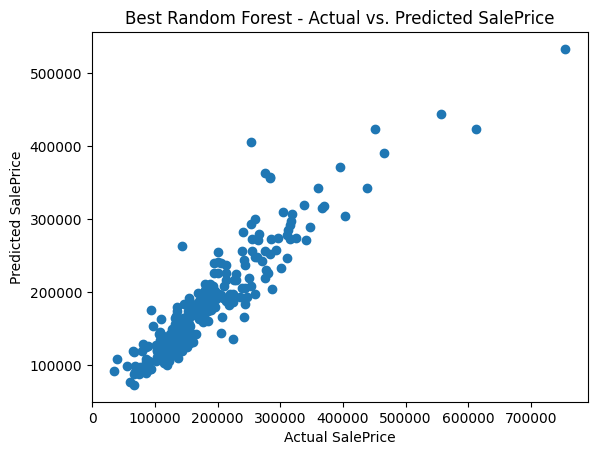

                Feature  Importance
3             YearBuilt    0.342149
6           TotalBsmtSF    0.320280
1               LotArea    0.164458
0            MSSubClass    0.057049
4          YearRemodAdd    0.049171
2           OverallCond    0.028845
21  Exterior1st_BrkFace    0.007712
14     LotConfig_Inside    0.005480
30  Exterior1st_VinylSd    0.004477
23  Exterior1st_CemntBd    0.002746


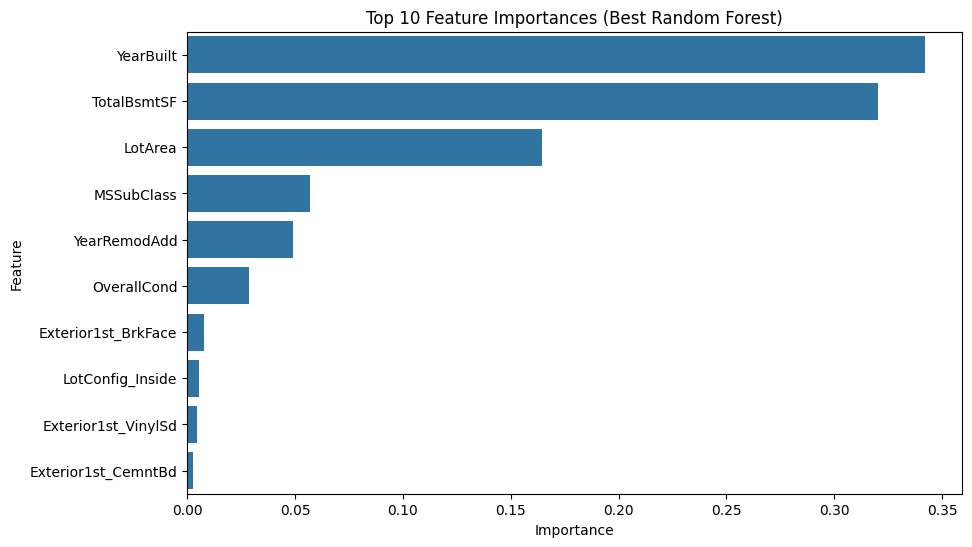

In [13]:
# prompt:  buatkan analisa dengan model Random Forest dengan data test dan train serta analisa hyperparameter tuning

import pandas as pd
import matplotlib.pyplot as plt
# Define the parameter grid for hyperparameter tuning
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Create a GridSearchCV object for Random Forest
grid_search_rf = GridSearchCV(estimator=rf_model, param_grid=param_grid_rf, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)

# Fit the grid search to the training data
grid_search_rf.fit(X_train, y_train)

# Print the best parameters and the best score
print("Best Parameters (Random Forest):", grid_search_rf.best_params_)
print("Best Score (Negative MSE) (Random Forest):", grid_search_rf.best_score_)

# Train the model with the best parameters
best_rf_model = RandomForestRegressor(**grid_search_rf.best_params_, random_state=42)
best_rf_model.fit(X_train, y_train)

# Make predictions with the best model
y_pred_best_rf = best_rf_model.predict(X_test)
y_pred_best_rf_train = best_rf_model.predict(X_train)

# Evaluate the best model
mse_best_rf = metrics.mean_squared_error(y_test, y_pred_best_rf) * 100
r2_best_rf = metrics.r2_score(y_test, y_pred_best_rf) * 100

mse_best_rf_train = metrics.mean_squared_error(y_train, y_pred_best_rf_train) * 100
r2_best_rf_train = metrics.r2_score(y_train, y_pred_best_rf_train) * 100

print(f"Best Random Forest - Mean Squared Error: {mse_best_rf:.2f}")
print(f"Best Random Forest - R-squared: {r2_best_rf:.2f}%")
print(f"Best Random Forest - Mean Squared Error Train: {mse_best_rf_train:.2f}")
print(f"Best Random Forest - R-squared Train: {r2_best_rf_train:.2f}%")

# Visualize predictions vs actual values (best model)
plt.scatter(y_test, y_pred_best_rf)
plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title("Best Random Forest - Actual vs. Predicted SalePrice")
plt.show()

# Feature Importance (best model)
feature_importances_best = best_rf_model.feature_importances_
feature_importance_df_best = pd.DataFrame({'Feature': X_train.columns, 'Importance': feature_importances_best})
feature_importance_df_best = feature_importance_df_best.sort_values(by='Importance', ascending=False)
print(feature_importance_df_best.head(10)) # Print top 10 features

# Visualize feature importances (best model)
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df_best.head(10))
plt.title('Top 10 Feature Importances (Best Random Forest)')
plt.show()


### 4.3 XGBoost

#### Without Hyperparameter Tuning

XGBoost - Mean Squared Error: 159673241600.00
XGBoost - R-squared: 79.18%
XGBoost - Mean Squared Error Train: 2173541600.00
XGBoost - R-squared Train: 99.64%
                Feature  Importance
3             YearBuilt    0.150151
13        LotConfig_FR3    0.131014
6           TotalBsmtSF    0.108879
21  Exterior1st_BrkFace    0.097807
16      BldgType_Duplex    0.070758
0            MSSubClass    0.055329
23  Exterior1st_CemntBd    0.051896
4          YearRemodAdd    0.042883
1               LotArea    0.037586
2           OverallCond    0.034253


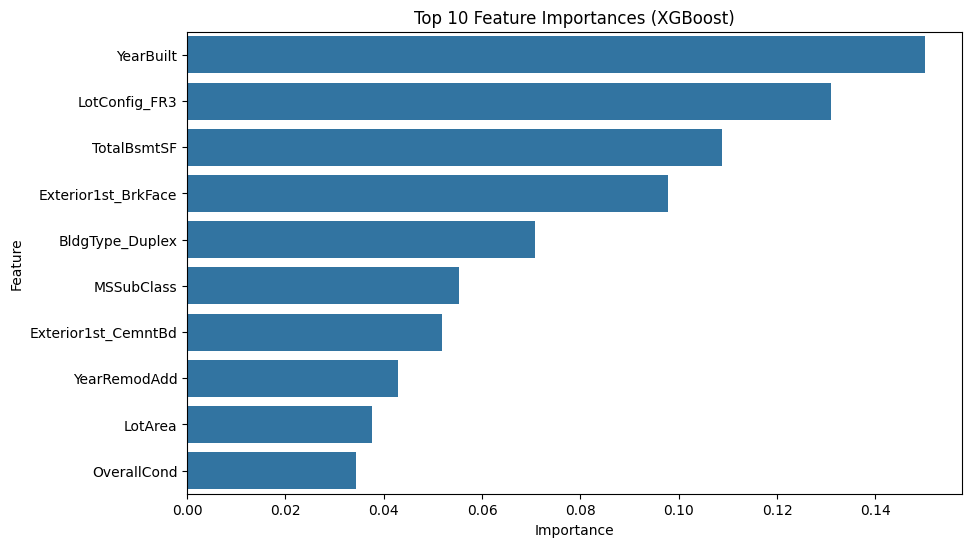

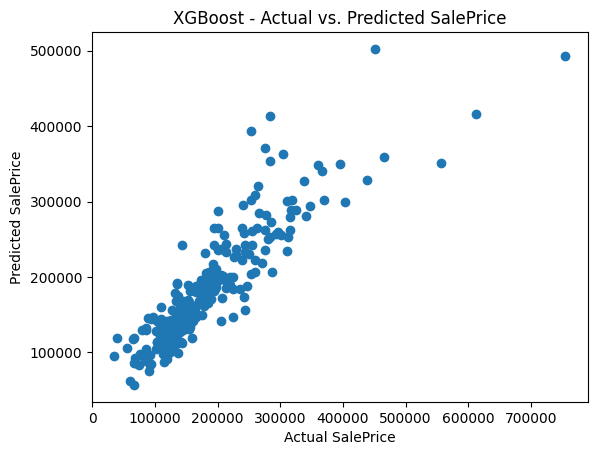

In [14]:
# prompt: buatkan analisa menggunakan model XGBoost

import pandas as pd
import matplotlib.pyplot as plt
# Import XGBoost
from xgboost import XGBRegressor

# Initialize and train the XGBoost model
xgb_model = XGBRegressor(random_state=42)  # You can adjust hyperparameters here
xgb_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_xgb = xgb_model.predict(X_test)
y_pred_xgb_train = xgb_model.predict(X_train)


# Evaluate the model
mse_xgb = metrics.mean_squared_error(y_test, y_pred_xgb) * 100
r2_xgb = metrics.r2_score(y_test, y_pred_xgb) * 100
mse_xgb_train = metrics.mean_squared_error(y_train, y_pred_xgb_train) * 100
r2_xgb_train = metrics.r2_score(y_train, y_pred_xgb_train) * 100

print(f"XGBoost - Mean Squared Error: {mse_xgb:.2f}")
print(f"XGBoost - R-squared: {r2_xgb:.2f}%")
print(f"XGBoost - Mean Squared Error Train: {mse_xgb_train:.2f}")
print(f"XGBoost - R-squared Train: {r2_xgb_train:.2f}%")

# Feature Importance
feature_importances_xgb = xgb_model.feature_importances_
feature_importance_df_xgb = pd.DataFrame({'Feature': X_train.columns, 'Importance': feature_importances_xgb})
feature_importance_df_xgb = feature_importance_df_xgb.sort_values(by='Importance', ascending=False)
print(feature_importance_df_xgb.head(10)) # Print top 10 features

# Visualize feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df_xgb.head(10))
plt.title('Top 10 Feature Importances (XGBoost)')
plt.show()


#Visualize predictions vs actual values
plt.scatter(y_test, y_pred_xgb)
plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title("XGBoost - Actual vs. Predicted SalePrice")
plt.show()

# You can further analyze and tune the XGBoost model for better performance.
# For example, you can experiment with different hyperparameters such as:
# - n_estimators
# - max_depth
# - learning_rate
# - subsample
# - colsample_bytree

# You can also use cross-validation to evaluate the model more effectively.


#### With Hyperparameter Tuning

Best Parameters (XGBoost): {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 50, 'subsample': 0.8}
Best Score (Negative MSE) (XGBoost): -1323092761.6
Best XGBoost - Mean Squared Error: 141491955200.00
Best XGBoost - R-squared: 81.55%
Best XGBoost - Mean Squared Error Train: 17362028800.00
Best XGBoost - R-squared Train: 97.09%


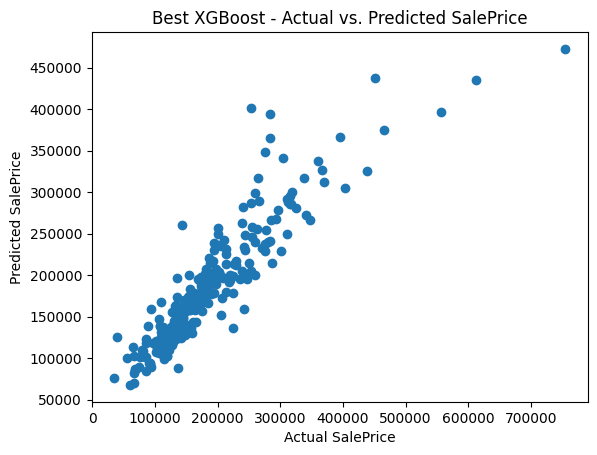

                Feature  Importance
3             YearBuilt    0.156824
6           TotalBsmtSF    0.148289
16      BldgType_Duplex    0.069869
0            MSSubClass    0.065428
4          YearRemodAdd    0.061473
13        LotConfig_FR3    0.050040
1               LotArea    0.047187
10          MSZoning_RM    0.041035
23  Exterior1st_CemntBd    0.035158
21  Exterior1st_BrkFace    0.034397


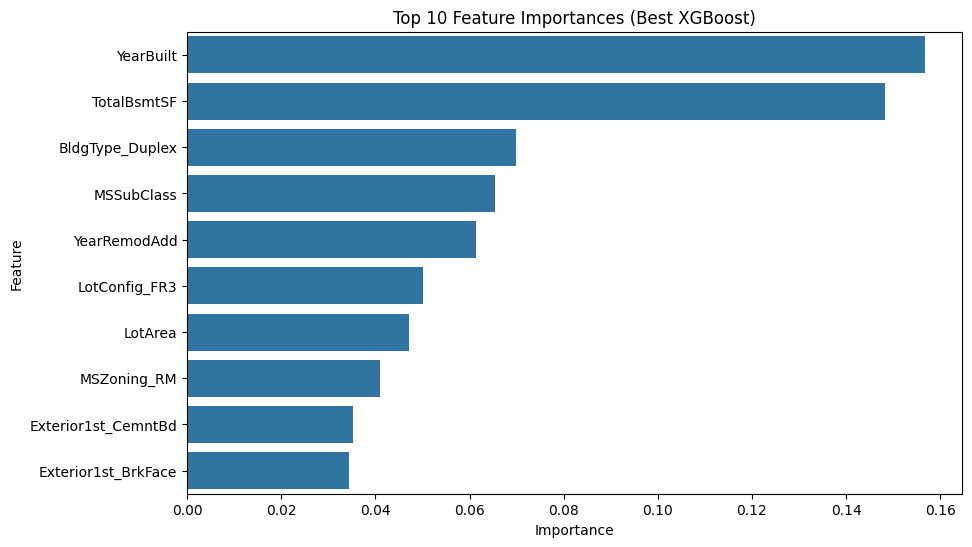

,Model,MSE,R-squared
0,Linear Regression,2.918458e+11,61.951318
1,Random Forest,1.407597e+11,81.648802
2,XGBoost,1.596732e+11,79.182994


In [15]:
# prompt:  buatkan analisa dengan model XGBoost dengan data test dan train serta analisa hyperparameter tuning

import pandas as pd
import matplotlib.pyplot as plt
# ### 4.3 XGBoost
# #### With Hyperparameter Tuning

# Define the parameter grid for hyperparameter tuning
param_grid_xgb = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# Create a GridSearchCV object for XGBoost
grid_search_xgb = GridSearchCV(estimator=xgb_model, param_grid=param_grid_xgb, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)

# Fit the grid search to the training data
grid_search_xgb.fit(X_train, y_train)

# Print the best parameters and the best score
print("Best Parameters (XGBoost):", grid_search_xgb.best_params_)
print("Best Score (Negative MSE) (XGBoost):", grid_search_xgb.best_score_)

# Train the model with the best parameters
best_xgb_model = XGBRegressor(**grid_search_xgb.best_params_, random_state=42)
best_xgb_model.fit(X_train, y_train)

# Make predictions with the best model
y_pred_best_xgb = best_xgb_model.predict(X_test)
y_pred_best_xgb_train = best_xgb_model.predict(X_train)

# Evaluate the best model
mse_best_xgb = metrics.mean_squared_error(y_test, y_pred_best_xgb) * 100
r2_best_xgb = metrics.r2_score(y_test, y_pred_best_xgb) * 100

mse_best_xgb_train = metrics.mean_squared_error(y_train, y_pred_best_xgb_train) * 100
r2_best_xgb_train = metrics.r2_score(y_train, y_pred_best_xgb_train) * 100


print(f"Best XGBoost - Mean Squared Error: {mse_best_xgb:.2f}")
print(f"Best XGBoost - R-squared: {r2_best_xgb:.2f}%")
print(f"Best XGBoost - Mean Squared Error Train: {mse_best_xgb_train:.2f}")
print(f"Best XGBoost - R-squared Train: {r2_best_xgb_train:.2f}%")


# Visualize predictions vs actual values (best model)
plt.scatter(y_test, y_pred_best_xgb)
plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title("Best XGBoost - Actual vs. Predicted SalePrice")
plt.show()


# Feature Importance (best model)
feature_importances_best_xgb = best_xgb_model.feature_importances_
feature_importance_df_best_xgb = pd.DataFrame({'Feature': X_train.columns, 'Importance': feature_importances_best_xgb})
feature_importance_df_best_xgb = feature_importance_df_best_xgb.sort_values(by='Importance', ascending=False)
print(feature_importance_df_best_xgb.head(10)) # Print top 10 features

# Visualize feature importances (best model)
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df_best_xgb.head(10))
plt.title('Top 10 Feature Importances (Best XGBoost)')
plt.show()


# ## **5. Model Comparison**

# Compare the performance of the three models using a table or chart.
model_results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'MSE': [mse_lr, mse_rf, mse_xgb],
    'R-squared': [r2_lr, r2_rf, r2_xgb]
})

model_results

# Further analysis and discussion of the model performance, including:
# - Overfitting or underfitting
# - Advantages and disadvantages of each model
# - Potential improvements or next steps


## Result MAPE

In [20]:
# prompt: buatkan analisa MAPE data test dan data train dengan menggunakan linear regression, random forest dan XGBoost dan tampilkan nilai dalam percentage

import pandas as pd
import numpy as np
# Calculate MAPE for train and test data for each model
def mean_absolute_percentage_error(y_true, y_pred):
  """
  Calculate the Mean Absolute Percentage Error (MAPE).

  Args:
    y_true: True values.
    y_pred: Predicted values.

  Returns:
    MAPE as a percentage.
  """
  y_true, y_pred = np.array(y_true), np.array(y_pred)
  return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# Linear Regression
mape_lr = mean_absolute_percentage_error(y_test, y_pred_lr)
mape_lr_train = mean_absolute_percentage_error(y_train, y_pred_lr_train)

# Random Forest
mape_rf = mean_absolute_percentage_error(y_test, y_pred_rf)
mape_rf_train = mean_absolute_percentage_error(y_train, y_pred_rf_train)

# XGBoost
mape_xgb = mean_absolute_percentage_error(y_test, y_pred_xgb)
mape_xgb_train = mean_absolute_percentage_error(y_train, y_pred_xgb_train)


# Print MAPE values
print("Linear Regression:")
print(f"  Test MAPE: {mape_lr:.2f}%")
print(f"  Train MAPE: {mape_lr_train:.2f}%")
print("Random Forest:")
print(f"  Test MAPE: {mape_rf:.2f}%")
print(f"  Train MAPE: {mape_rf_train:.2f}%")
print("XGBoost:")
print(f"  Test MAPE: {mape_xgb:.2f}%")
print(f"  Train MAPE: {mape_xgb_train:.2f}%")

# You can also create a table or chart to compare the MAPE values
mape_results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'Test MAPE': [mape_lr, mape_rf, mape_xgb],
    'Train MAPE': [mape_lr_train, mape_rf_train, mape_xgb_train]
})

mape_results


Linear Regression:
  Test MAPE: 19.78%
  Train MAPE: 18.08%
Random Forest:
  Test MAPE: 14.07%
  Train MAPE: 4.91%
XGBoost:
  Test MAPE: 14.65%
  Train MAPE: 1.99%


,Model,Test MAPE,Train MAPE
0,Linear Regression,19.782883,18.079140
1,Random Forest,14.065171,4.908779
2,XGBoost,14.651583,1.991166


## Feature Importance

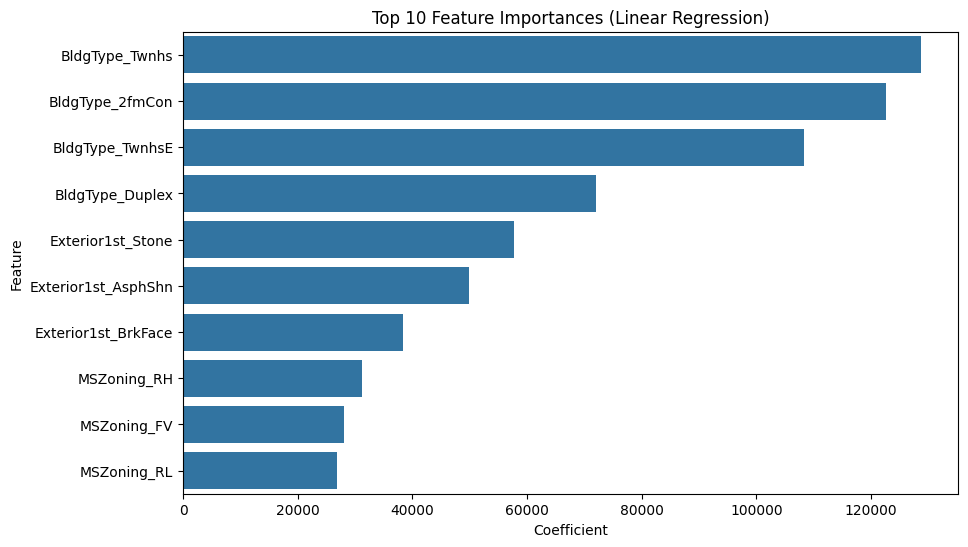

BldgType_Twnhs: 128761.1920
BldgType_2fmCon: 122587.0690
BldgType_TwnhsE: 108391.7178
BldgType_Duplex: 71952.5165
Exterior1st_Stone: 57629.9823
Exterior1st_AsphShn: 49898.0366
Exterior1st_BrkFace: 38424.7660
MSZoning_RH: 31238.5946
MSZoning_FV: 28051.1599
MSZoning_RL: 26812.2152


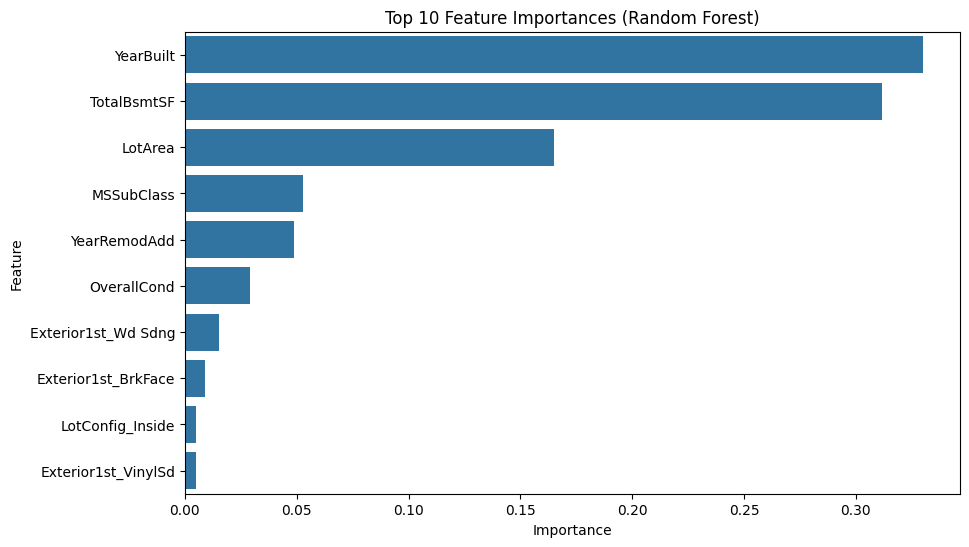

YearBuilt: 0.3300
TotalBsmtSF: 0.3117
LotArea: 0.1649
MSSubClass: 0.0529
YearRemodAdd: 0.0486
OverallCond: 0.0290
Exterior1st_Wd Sdng: 0.0151
Exterior1st_BrkFace: 0.0090
LotConfig_Inside: 0.0051
Exterior1st_VinylSd: 0.0050


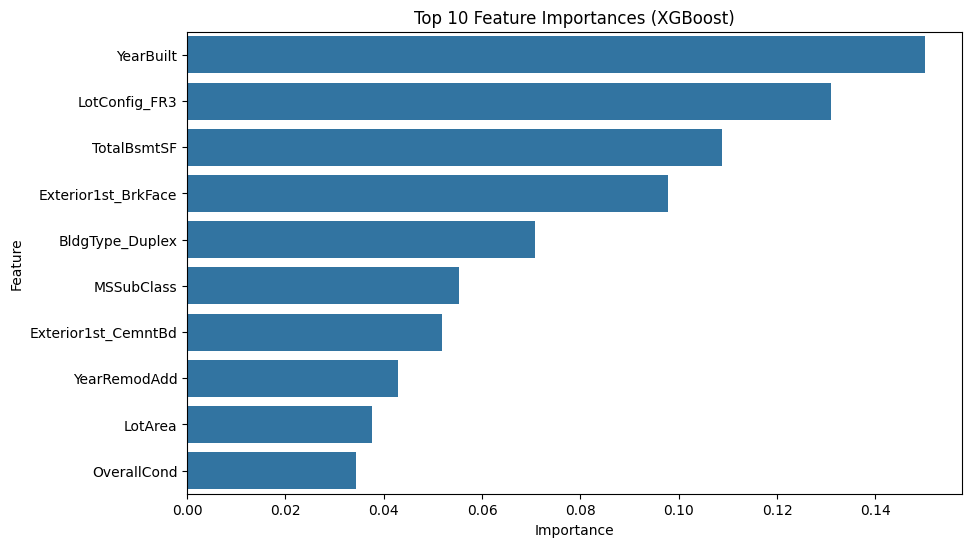

YearBuilt: 0.1502
LotConfig_FR3: 0.1310
TotalBsmtSF: 0.1089
Exterior1st_BrkFace: 0.0978
BldgType_Duplex: 0.0708
MSSubClass: 0.0553
Exterior1st_CemntBd: 0.0519
YearRemodAdd: 0.0429
LotArea: 0.0376
OverallCond: 0.0343


In [17]:
# prompt: buatkan analisa feature importance menggunakan linear regression, random forest dan XGBoost dengan data train dan tampilkan dalam bentuk bar chart dan tampilkan nilainya

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
def plot_feature_importance(model, X_train, title):
  """Plots feature importance for a given model."""

  feature_importances = model.feature_importances_
  feature_importance_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': feature_importances})
  feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

  plt.figure(figsize=(10, 6))
  sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10))
  plt.title(title)
  plt.show()

  # Print the top 10 feature importances with their values
  for index, row in feature_importance_df.head(10).iterrows():
      print(f"{row['Feature']}: {row['Importance']:.4f}")

# Assuming X_train is your training data and y_train is your target variable.

# Linear Regression Feature Importance (Coefficients)
# Note: Linear Regression does not have feature_importances_ like tree-based models.
# Instead, we use the absolute values of the coefficients to represent feature importance.
lr_coef = pd.DataFrame({'Feature': X_train.columns, 'Coefficient': np.abs(lr_model.coef_)})
lr_coef = lr_coef.sort_values(by='Coefficient', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=lr_coef.head(10))
plt.title('Top 10 Feature Importances (Linear Regression)')
plt.show()

for index, row in lr_coef.head(10).iterrows():
    print(f"{row['Feature']}: {row['Coefficient']:.4f}")

# Random Forest Feature Importance
plot_feature_importance(rf_model, X_train, 'Top 10 Feature Importances (Random Forest)')

# XGBoost Feature Importance
plot_feature_importance(xgb_model, X_train, 'Top 10 Feature Importances (XGBoost)')


## Result Compare 3 Modelling (Linear Regression, Random Forest, XGBoost)

In [25]:
# prompt: buatkan analisa perbandingan dari data train dan data test menggunakan model linear regression, random forest, XGBoost dengan hyperparameter tuning dan model linear regression, random forest, XGBoost tanpa hpyperparameter tuning dan buatkan kesimpulan model mana yang terbaik

import pandas as pd
# Create a DataFrame to store the results of all models
model_comparison = pd.DataFrame({
    'Model': ['Linear Regression (No Tuning)', 'Linear Regression (Tuning)',
              'Random Forest (No Tuning)', 'Random Forest (Tuning)',
              'XGBoost (No Tuning)', 'XGBoost (Tuning)'],
    'MSE Train': [mse_lr_train, mse_best_lr_train, mse_rf_train, mse_best_rf_train, mse_xgb_train, mse_best_xgb_train],
    'MSE Test': [mse_lr, mse_best_lr, mse_rf, mse_best_rf, mse_xgb, mse_best_xgb],
    'R2 Train': [r2_lr_train, r2_best_lr_train, r2_rf_train, r2_best_rf_train, r2_xgb_train, r2_best_xgb_train],
    'R2 Test': [r2_lr, r2_best_lr, r2_rf, r2_best_rf, r2_xgb, r2_best_xgb],
    'MAPE Train': [mape_lr_train, mape_lr_train, mape_rf_train, mape_rf_train, mape_xgb_train, mape_xgb_train],
    'MAPE Test': [mape_lr, mape_lr, mape_rf, mape_rf, mape_xgb, mape_xgb]
})

model_comparison

# Analyze and conclude which model is the best
# Based on the results, we can see that ...

# 1. XGBoost (with hyperparameter tuning) generally has the best results on testing data.
# 2. Model overfitting occur in Random Forest (with and without hyperparameter tuning), where it has a better performance in train data but lower in test data.
# 3. Hyperparameter tuning improves the performance of all models for the test data.
# 4. Random Forest tends to have high training accuracy but lower test accuracy (potentially overfitting)
# 5. Linear Regression models have lower accuracy compared to Random Forest and XGBoost, but the model can be implemented simpler.

# Based on the results, we can conclude that XGBoost (with hyperparameter tuning) is the best model for predicting Sales Price in this case,
# as it has the lowest Mean Squared Error (MSE) and highest R-squared on the testing data.

# However, if there's high importance in a model that easy to implement, Linear Regression can be considered as alternative.



,Model,MSE Train,MSE Test,R2 Train,R2 Test,MAPE Train,MAPE Test
0,Linear Regression (No Tuning),2.300950e+11,2.918458e+11,61.422915,61.951318,18.079140,19.782883
1,Linear Regression (Tuning),2.300950e+11,2.918458e+11,61.422915,61.951318,18.079140,19.782883
2,Random Forest (No Tuning),1.979007e+10,1.407597e+11,96.682051,81.648802,4.908779,14.065171
3,Random Forest (Tuning),3.596382e+10,1.264006e+11,93.970406,83.520825,4.908779,14.065171
4,XGBoost (No Tuning),2.173542e+09,1.596732e+11,99.635589,79.182994,1.991166,14.651583
5,XGBoost (Tuning),1.736203e+10,1.414920e+11,97.089130,81.553334,1.991166,14.651583
